## Downscaling and moving windows
- Downscaling NDVI and NDWI rasters to 30m to have same-level scale with LST images 
- computing moving windows and study the correlations with LST depending on the size of the window.


### libraries and general paths

In [1]:
!pip install rasterio
!pip install geopandas
!pip install tqdm
!pip install matplotlib
!pip install scipy
!pip install scikit-gstat


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import glob
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from rasterio.plot import plotting_extent
import numpy as np
import geopandas as gpd
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr
from scipy.ndimage import uniform_filter
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import convolve


In [3]:
# Rasters
lst_path = '../../../datos-notebooks/1.HR-data-bologna/1.0.base-data/LST/LC09_L2SP_192029_20240809_20240810_02_T1_ST_B10.tif' 
lst_cropped_path = '../../../datos-notebooks/1.HR-data-bologna/1.0.base-data/LST/LST_cropped_celsius.tif' # values out of bound are 0
lst_clipped_path = '../../../datos-notebooks/1.HR-data-bologna/1.0.base-data/LST/LST_clipped_celsius.tif' #values out of bound are nan
mosaic_ndvi_path = "../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/mosaics/ndvi_mosaic-2.tif"  
mosaic_ndwi_path = "../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/mosaics/ndwi_mosaic.tif"  
# Boundary
bound = '../../../datos-notebooks/1.HR-data-bologna/1.0.base-data/vectors/bologne_boundary.geojson'
gdf = gpd.read_file(bound)

# Folders
output_folder_downscaling = "../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/30m/"   
os.makedirs(output_folder_downscaling, exist_ok=True)
output_folder_mw = "../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/moving-windows/"
os.makedirs(output_folder_mw, exist_ok=True)  

### cropping and transforming the LST Image from Kelvin to Celsius

In [ ]:
# --- Load, crop and transform LST ---
with rasterio.open(lst_path) as src_lst:
    lst_crs = src_lst.crs
    gdf_lst = gdf.to_crs(lst_crs)
    lst_crop, lst_transform = mask(src_lst, gdf_lst.geometry, crop=True)
    lst_crop = lst_crop[0].astype(float) * 0.00341802 - 124.15  # transformation
    lst_crop[lst_crop < 0] = np.nan # --- Assign nodata to LST < 0 --- (nodata is -124.15 now)

# save the result
with rasterio.open(
    lst_cropped_path,
    "w",
    driver="GTiff",
    height=lst_crop.shape[0],
    width=lst_crop.shape[1],
    count=1,
    dtype=lst_crop.dtype,
    crs=lst_crs,
    transform=lst_transform,
) as dst:
    dst.write(lst_crop, 1)

In [ ]:
with rasterio.open(lst_cropped_path) as lst_crop:
    lst_crop = lst_crop.read(1)  
    
plt.figure(figsize=(8,6))
plt.imshow(lst_crop, cmap='hot')  
plt.colorbar(label='°C')
plt.title('LST Cropped')
plt.show()

In [ ]:
# Clip LST raster 

with rasterio.open(lst_cropped_path) as src:
    # Convert boundary to raster CRS
    boundary_crs = gdf.to_crs(src.crs)
    geoms = [boundary_crs.geometry.union_all().__geo_interface__]  # avoids deprecation warning

    # Clip raster to city boundary
    clipped_arr, clipped_transform = mask.mask(
        src,
        geoms,
        crop=True,
        nodata=np.nan
    )

    # Convert to float and handle original nodata
    clipped_arr = clipped_arr.astype("float32")
    if src.nodata is not None:
        clipped_arr[clipped_arr == src.nodata] = np.nan

    # Remove extra dimensions
    clipped_arr = clipped_arr.squeeze()

    # Update metadata
    meta = src.meta.copy()
    meta.update({
        "height": clipped_arr.shape[0],
        "width": clipped_arr.shape[1],
        "transform": clipped_transform,
        "dtype": "float32",
        "nodata": np.nan
    })

# Save
with rasterio.open(lst_clipped_path, "w", **meta) as dst:
    dst.write(clipped_arr, 1)

### downscaling

1. Converts the class of interest into a binary mask (1 if pixel belongs to the class, 0 otherwise).  
2. Resamples and aggregates the binary mask to the 30 m LST grid using the average, computing the proportion of pixels of that class within each 30 m pixel, aligned with a reference LST raster. 

#### NDVI

In [4]:
# NDVI
# Parameters
classes = [0, 0.5, 1]  # NDVI classes correspond to no vegetation, medium veg, dense veg respectively 

# open LST for spatial reference
with rasterio.open(lst_cropped_path) as src_lst:
    lst_profile = src_lst.profile
    lst_transform = src_lst.transform
    lst_crs = src_lst.crs
    lst_shape = (src_lst.height, src_lst.width)

# Initialize accumulators by class
accumulators = {val: np.zeros(lst_shape, dtype=np.float32) for val in classes}

# Read NDVI mosaic
with rasterio.open(mosaic_ndvi_path) as src_ndvi:
    ndvi_data = src_ndvi.read(1).astype(float)
    ndvi_transform = src_ndvi.transform
    ndvi_crs = src_ndvi.crs

# Process classes
for val in tqdm(classes, desc="Reprojecting NDVI classes"):
    mask_class = (ndvi_data == val).astype(float)
    resampled = np.empty(lst_shape, dtype=np.float32)
    
    reproject(
        source=mask_class,
        destination=resampled,
        src_transform=ndvi_transform,
        src_crs=ndvi_crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )
    
    accumulators[val] += resampled  

# Save results
for val in classes:
    out_profile = lst_profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
    out_path = f"{output_folder_downscaling}ndvi_class{str(val).replace('.', 'p')}_30m.tif"
    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(accumulators[val], 1)

    print(f"Class {val} saved in {out_path}")
    
# Very heavy, does not run in jupyterlab with 8gb of RAM (BDT platform)

Reprojecting NDVI classes: 100%|██████████| 3/3 [01:46<00:00, 35.67s/it]


Class 0 saved in ../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/30m/ndvi_class0_30m.tif
Class 0.5 saved in ../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/30m/ndvi_class0p5_30m.tif
Class 1 saved in ../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/30m/ndvi_class1_30m.tif


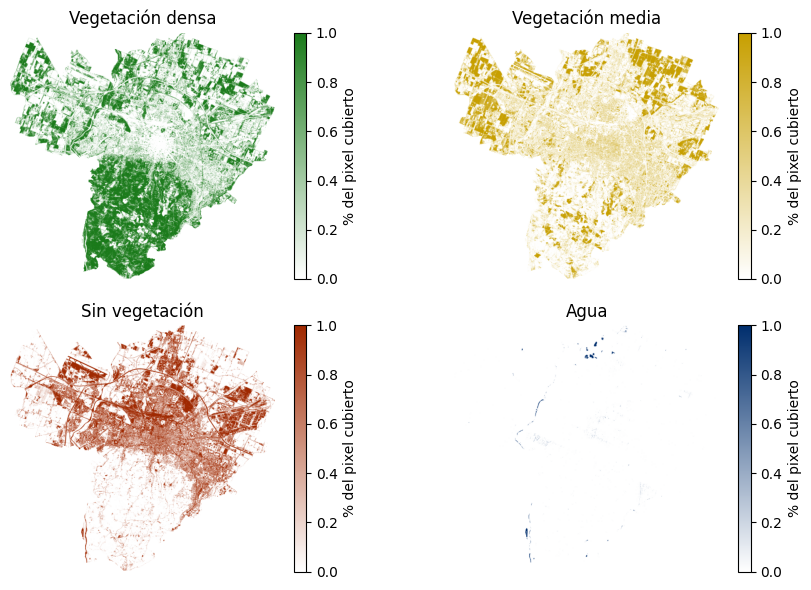

In [5]:
from matplotlib.colors import LinearSegmentedColormap

white_to_green = LinearSegmentedColormap.from_list(
    "white_green", ["white", "#1a7a1a"]
)

white_to_yellow = LinearSegmentedColormap.from_list(
    "white_yellow", ["white", "#C79F00"]
)

white_to_red = LinearSegmentedColormap.from_list(
    "white_red", ["white", "#9F2800"]
)

white_to_blue = LinearSegmentedColormap.from_list(
    "white_blue", ["white", "#002E6D"]
)


ndvi_paths = {
    "Vegetación densa": os.path.join(output_folder_downscaling, "ndvi_class1_30m.tif"),
    "Vegetación media": os.path.join(output_folder_downscaling, "ndvi_class0p5_30m.tif"),
    "Sin vegetación": os.path.join(output_folder_downscaling, "ndvi_class0_30m.tif"),
    "Agua": os.path.join(output_folder_downscaling, "ndwi_class1_30m.tif")
}

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for ax, (label, path) in zip(axes, ndvi_paths.items()):
    if label == "Sin vegetación":
        cmap = white_to_red

    elif label == "Vegetación media":
        cmap = white_to_yellow
        
    elif label == "Vegetación densa":
        cmap = white_to_green
    
    else:
        cmap = white_to_blue

    with rasterio.open(path) as src:
        out_image, out_transform = mask(src, gdf.geometry, crop=True)
        out_image = out_image[0]

        img = ax.imshow(out_image, cmap=cmap)
        ax.set_title(label)
        ax.axis("off")

    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("% del pixel cubierto")

plt.tight_layout()
plt.show()


#### NDWI

In [ ]:
# Parameters
classes = [0, 1]                                        

# open LSTfor spatial reference 
with rasterio.open(lst_cropped_path) as src_lst:
    lst_profile = src_lst.profile
    lst_transform = src_lst.transform
    lst_crs = src_lst.crs
    lst_shape = (src_lst.height, src_lst.width)

# Initialize accumulators by class
accumulators = {val: np.zeros(lst_shape, dtype=np.float32) for val in classes}

# Read NDWI mosaic
with rasterio.open(mosaic_ndwi_path) as src_ndwi:
    ndwi_data = src_ndwi.read(1).astype(float)
    ndwi_transform = src_ndwi.transform
    ndwi_crs = src_ndwi.crs
    
# Process classes
for val in tqdm(classes, desc="Reprojecting NDWI classes"):
    mask_class = (ndwi_data == val).astype(float)
    resampled = np.empty(lst_shape, dtype=np.float32)

    reproject(
        source=mask_class,
        destination=resampled,
        src_transform=ndwi_transform,
        src_crs=ndwi_crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )

    accumulators[val] += resampled  # in this case, it's just one mosaic

# Save results
for val in classes:
    out_profile = lst_profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
    out_path = f"{output_folder_downscaling}ndwi_class{str(val).replace('.', 'p')}_30m.tif"

    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(accumulators[val], 1)

    print(f"Class {val} saved in {out_path}")

# Very heavy, does not run in jupyterlab with 8gb of RAM

In [ ]:
ndwi_paths = {
    "Class 1": os.path.join(output_folder_downscaling, "ndwi_class1_30m.tif"),
    "Agua": os.path.join(output_folder_downscaling, "ndwi_class0_30m.tif")
}


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

colors = ["white", "blue", "lightgrey"]
custom_cmap = LinearSegmentedColormap.from_list("white_blue_purple", colors)

for ax, (label, path) in zip(axes, ndwi_paths.items()):
    with rasterio.open(path) as src:
        out_image, out_transform = mask(src, gdf.geometry, crop=True)
        out_image = out_image[0]  

        img = ax.imshow(out_image, cmap=custom_cmap)
        ax.set_title(label)
        ax.axis("off")

    # Add individual colorbar for each subplot
    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("% of pixels in class")

plt.tight_layout()
plt.show()


### moving windows 

In [8]:
def distance_weighted_kernel(size):
    """Create a distance-weighted Gaussian kernel."""
    assert size % 2 == 1, "Window size must be odd"
    center = size // 2
    y, x = np.ogrid[:size, :size]
    distance = np.sqrt((x - center)**2 + (y - center)**2)
    sigma = size / 4  # controls smoothing strength
    weights = np.exp(-(distance**2) / (2 * sigma**2))
    weights /= weights.sum()  # normalize to sum=1
    return weights


def moving_window_weighted(array, kernel):
    """Apply distance-weighted convolution."""
    return convolve(array, kernel, mode='nearest')


#### NDVI

In [9]:
ndvi_paths = {
    "class_1": os.path.join(output_folder_downscaling, "ndvi_class1_30m.tif"),
    "class_0p5": os.path.join(output_folder_downscaling, "ndvi_class0p5_30m.tif"),
    "class_0": os.path.join(output_folder_downscaling, "ndvi_class0_30m.tif")
}

output_folder_mw_ndvi = os.path.join(output_folder_mw, "ndvi/")
os.makedirs(output_folder_mw_ndvi, exist_ok=True)
    

In [10]:
# Loop over classes
for class_name, path in ndvi_paths.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        profile = src.profile

        # Loop over window sizes (ONLY odd sizes)
        for window_size in range(1, 151, 2):  
            kernel = distance_weighted_kernel(window_size)
            smoothed = moving_window_weighted(data, kernel)

            # Save raster
            out_profile = profile.copy()
            out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
            out_path = os.path.join(
                output_folder_mw_ndvi, 
                f"{class_name}_window{window_size}.tif"
            )

            with rasterio.open(out_path, "w", **out_profile) as dst:
                dst.write(smoothed.astype(np.float32), 1)


In [ ]:
# plot for one class

class_n = "class_1"

fig, axes = plt.subplots(4, 3, figsize=(8, 8))  
axes = axes.flatten()

for window_size in range(1, 21,2):
    raster_path = os.path.join(output_folder_mw_ndvi, f"{class_n}_window{window_size}.tif")
    with rasterio.open(raster_path) as src:
        data, out_transform = mask(src, gdf.geometry, crop=True)
        data = data[0]

    ax = axes[(window_size - 1)//2]
    im = ax.imshow(data, cmap="YlGn")
    ax.set_title(f"Window {window_size}x{window_size}")
    ax.axis("off")

fig.suptitle(f"{class_n} - Moving window", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
classes = ["class_1", "class_0p5", "class_0"]

window_sizes = list(range(1, 21, 2))  # odd windows


for class_name in classes:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8)) 
    axes = axes.flatten()

    cmap = "Greys" if class_name == "class_0" else "YlGn"

    for ax, w in zip(axes, window_sizes):
        raster_path = os.path.join(
            output_folder_mw_ndvi, 
            f"{class_name}_window{w}.tif"
        )

        with rasterio.open(raster_path) as src:
            data, _ = mask(src, gdf.geometry, crop=True)
            data = data[0]

        im = ax.imshow(data, cmap=cmap)
        ax.set_title(f"Window {w}x{w}")
        ax.axis("off")

    fig.suptitle(f"{class_name} - Distance-weighted moving window", fontsize=16)
    plt.tight_layout()
    plt.show()





#### NDWI

In [ ]:
# NDWI Rasters by class
ndwi_rasters = {
    "class_1": os.path.join(output_folder_downscaling, "ndwi_class1_30m.tif"),
    "class_0": os.path.join(output_folder_downscaling, "ndwi_class0_30m.tif")
}

output_folder_mw_ndwi = os.path.join(output_folder_mw, "ndwi/")
os.makedirs(output_folder_mw_ndwi, exist_ok=True)


In [ ]:
# Loop over classes
for class_name, path in ndwi_rasters.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        profile = src.profile

        # Loop over window sizes (ONLY odd sizes)
        for window_size in range(1, 201, 2):  
            kernel = distance_weighted_kernel(window_size)
            smoothed = moving_window_weighted(data, kernel)

            # Save raster
            out_profile = profile.copy()
            out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
            out_path = os.path.join(
                output_folder_mw_ndwi, 
                f"{class_name}_window{window_size}.tif"
            )

            with rasterio.open(out_path, "w", **out_profile) as dst:
                dst.write(smoothed.astype(np.float32), 1)



In [ ]:
classes = ["class_1", "class_0"]

# Define custom colormap
colors = ["white", "blue", "lightgrey"]
custom_cmap = LinearSegmentedColormap.from_list("white_blue_purple", colors)

window_sizes = list(range(1, 21, 2))  # odd windows only (1..19)

for class_name in classes:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # 10 windows
    axes = axes.flatten()

    for ax, w in zip(axes, window_sizes):
        raster_path = os.path.join(
            output_folder_mw_ndwi, 
            f"{class_name}_window{w}.tif"
        )

        with rasterio.open(raster_path) as src:
            data, _ = mask(src, gdf.geometry, crop=True)
            data = data[0]

        im = ax.imshow(data, cmap=custom_cmap)
        ax.set_title(f"Window {w}x{w}")
        ax.axis("off")

    fig.suptitle(f"{class_name} - Distance-weighted moving window", fontsize=16)
    plt.tight_layout()
    plt.show()


### Correlations with LST

#### all

In [11]:
# Paths
ndvi_folder = "../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/moving-windows/ndvi/"
ndwi_folder = "../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/moving-windows/ndwi/"

# general parameters
window_sizes = range(1, 101, 2)

# --- Load LST ---
with rasterio.open(lst_clipped_path) as lst:
    lst_crs = lst.crs
    lst_clip = lst.read(1)          
    lst_transform = lst.transform   

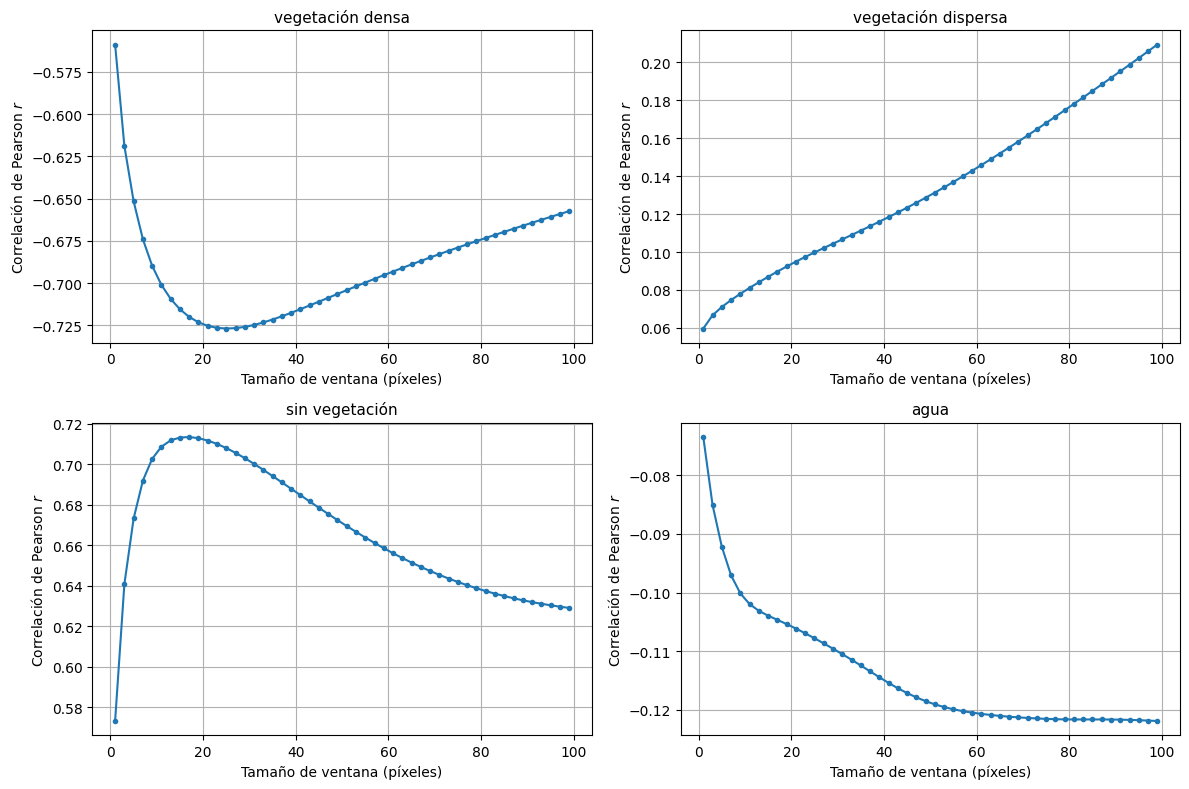

In [6]:
series = {
    "vegetación densa":   (ndvi_folder, "class_1_window{w}.tif"),
    "vegetación dispersa": (ndvi_folder, "class_0p5_window{w}.tif"),
    "sin vegetación":   (ndvi_folder, "class_0_window{w}.tif"),
    "agua":   (ndwi_folder, "class_1_window{w}.tif"),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (label, (folder, pattern)) in zip(axes, series.items()):
    correlations = []
    for w in window_sizes:
        path = os.path.join(folder, pattern.format(w=w))
        with rasterio.open(path) as src:
            data_crop, _ = mask(src, gdf.geometry, crop=True)
            data_crop = data_crop[0].astype(float)

        valid = ~np.isnan(lst_clip)
        corr = np.corrcoef(data_crop[valid], lst_clip[valid])[0, 1]
        correlations.append(corr)

    ax.plot(window_sizes, correlations, marker='o', markersize=3)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Tamaño de ventana (píxeles)")
    ax.set_ylabel("Correlación de Pearson $r$")
    ax.grid(True)

plt.tight_layout()
plt.show()

#### NDVI-LST

##### CLASS 1 (dense vegetation)

In [ ]:
correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(ndvi_folder, f"class_1_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    # Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# Plot
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Tamaño de ventana (pixeles)")
plt.ylabel("Valor de correlación "r"")
plt.title("Vegetación densa")
plt.grid(True)
plt.show()



##### Class 0 (no vegetation)

In [ ]:

correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(ndvi_folder, f"class_0_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        gdf_ndvi = gdf.to_crs(src_ndvi.crs)
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf_ndvi.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDVI class 0 – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()



##### Class 0.5 (mid vegetation)

In [ ]:
correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(ndvi_folder, f"class_0p5_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    # Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# Plot
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDVI class 0.5 – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()


#### NDWI-LST

In [ ]:
correlations = []

for w in window_sizes:
    ndwi_path = os.path.join(ndwi_folder, f"class_1_window{w}.tif")
    with rasterio.open(ndwi_path) as src_ndwi:
        gdf_ndwi = gdf.to_crs(src_ndwi.crs)
        ndwi_crop, ndwi_transform = mask(src_ndwi, gdf_ndwi.geometry, crop=True)
        ndwi_crop = ndwi_crop[0].astype(float)

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  
    ndwi_vals = ndwi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndwi_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDWI class 1 – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()